# Create a Custom TLE Catalog with Tudatpy's Space-Track Downloader

> **DISCLAIMER(IMPORTANT!)**:
> 
> In order to run this example, **you must first activate an account on [Space-Track.org](https://www.space-track.org/auth/login)**.
> 
> Avoid running this scirpt multiple times in a row, or your Space-Track account could be suspended. **Tudatpy Users are expected to read and comply with the [API Use Guidelines](https://www.space-track.org/documentation#:~:text=the%20production%20server.-,API%20Use%20Guidelines,-API%20Throttling%3A).**
> 
# Objectives
This example showcases how to use Tudatpy's `SpacetrackQuery` and `OMMUTils` classes to:

1) **download customized satellite data from [Space-Track.org](https://www.space-track.org/auth/login)** into a local catalog;
2) updating the local catalog via **additional requests**;
3) **retrieving relevant data about the downloaded satellites (**identifiers, orbital elements, TLEs**);
4) propagating TLE's initial state;
5) produce corresponding ground plot for all satellites in your catalog;

More specifically, we will request a download of the **first 5 high-inclination satellites**, ordered by descending reference epoch, as they are given in the Space-Track's `gp current` catalog. Two queries will also be performed to showcase how the `query_from_query_builder_url` function works, and to download TLEs from a given epoch, that do not change with time (this is for the sake of reproducibility of the example itself, as you will see in the final plot). We will then update the catalog to add the **first 10 low-inclination satellites**, and print their orbital elements and their object names. Finally, we will propagate their orbits **starting from a TLE-retrieved initial state**, also showing their corresponding **ground plots**.

## Imports and Load SPICE Kernels
As in most Tudatpy's examples, we import all relevant modules and load our set of spice standard kernels.

In [1]:
from tudatpy.data.spacetrack import SpaceTrackQuery, OMMUtils
from tudatpy.dynamics import environment_setup, propagation_setup, simulator, environment
from tudatpy.astro import time_representation
from tudatpy.util import result2array
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from tudatpy.interface import spice
from matplotlib.patches import Rectangle, ConnectionPatch

# Load Spice kernels
spice.load_standard_kernels()

## Initialize SpaceTrackQuery
As mentioned in the introduction, you need to have an active account on [Space-Track.org](https://www.space-track.org/auth/login)  to download data via Tudatpy's **SpaceTrackQuery** class.

Once you have your username and password set up, you can set them as [**environment variables**](https://fastapi.tiangolo.com/environment-variables/) by typing the following lines in your terminal before running the example:

`export SPACETRACK_USER='<your_spacetrack_username>'`
\
`export SPACETRACK_PASS='<your_spacetrack_password>'`

Or alternatively run the snippet and interactively insert your inputs, as requested by the _login() method of the SpaceTrackQuery class, which is triggered automatically if environment variables (`username`, `password`) evaluate to `None`, i.e. if they have not been set. 

In [ ]:
# Initialize SpaceTrack
username = os.getenv("SPACETRACK_USER")
password = os.getenv("SPACETRACK_PASS")
spacetrack_query = SpaceTrackQuery(
    username=username,
    password=password,
)

## Select custom catalog path
We create a new json file to store our SpaceTrack response (this will be a list of json objects). 

In [3]:
custom_catalog_file = "my_polar_and_equatorial_satellites.json"
filepath = os.path.join(spacetrack_query.tle_data_folder, custom_catalog_file)

## Download High-Inclination (~Polar) Satellites
We want to download the first 5 (ordered by descending TLE reference epoch) high-inclination satellites to the earlier-define `custom_catalog_file`. The flag update_existing can be set to False, because the catalog is currently empty.

In [4]:
# --- STEP 1 & 2: Fetch Data for Polar Satellites ---
high_inclination_satellites = spacetrack_query.filtered_by_oe_dict(
    filter_oe_dict={'INCLINATION': (97.0, 99.0)},
    limit=5,
    output_file=custom_catalog_file,
    update_existing=False
)

Fetching data for my_polar_and_equatorial_satellites.json...
Overwrite mode. Saving my_polar_and_equatorial_satellites.json...


## Download Specific Satellites

If you are familiar with Space-Track.org, you'll know that they provide a **Query Builder**. With Space-Track.org's Query Builder, users can select the objects they want to download, and be provided with the correct endpoint (url). 

The SpaceTrackQuery's function `query_from_query_builder_url` allow you to copy such a created url from Space-Track directly into your Tudatpy script. For the sake of this example, we used Space-Track Query Builder to retrieve TLEs for satellites **TJS-15** and **LUCH 5V**, adding an EPOCH filter allowing us to only get the single existing TLE between Feb 18 and Feb 19, 2026. This is because TLEs will in general be updated over time, and the only way to keep this example semi-reproducible is to always query the same TLE for these two objects. This will in turn provide the same plot at all times (see cells below). 

We want to add the downloaded satellites to the already existing custom catalog. In Tudatpy's SpaceTrackQuery, his can be achieved by selecting the corresponding `update_existing` flag to `True`.

In [5]:
custom_satellite_tjs_15 = spacetrack_query.query_from_query_builder_url(
    'https://for-testing-only.space-track.org/basicspacedata/query/class/gp/OBJECT_NAME/TJS-15/EPOCH/%3E2025-02-18%3C2025-02-19/orderby/EPOCH%20asc/format/json',
    output_file=custom_catalog_file,
    update_existing=True,
)

custom_satellite_luch_5v = spacetrack_query.query_from_query_builder_url(
    'https://for-testing-only.space-track.org/basicspacedata/query/class/gp/OBJECT_NAME/LUCH 5V/EPOCH/%3E2025-02-18%3C2025-02-19/orderby/EPOCH%20asc/format/json',
    output_file=custom_catalog_file,
    update_existing=True,
)

Fetching data for my_polar_and_equatorial_satellites.json...
Merge requested. Updating my_polar_and_equatorial_satellites.json...
Fetching data for my_polar_and_equatorial_satellites.json...
Merge requested. Updating my_polar_and_equatorial_satellites.json...


## Download Low-Inclination (~Equatorial) Satellites
We also want to **download the first 10 low-inclination satellites** ordered by descending TLE reference epoch, and add them to the already existing catalog. This can be achieved by selecting the corresponding `filter_oe_dict` and using the `update_existing` flag to `True`. This will update the already existing `custom_catalog_file` by merging the new downloaded jsons into it. At the end, we will have a custom catalog comprising 15 satellites, 10 of which are characterized by low inclinations.

In [6]:
# --- STEP 1 & 2: Fetch Data for Equatorial Satellites, Use update_existing = True ---

low_inclination_satellites = spacetrack_query.filtered_by_oe_dict(
    filter_oe_dict={'INCLINATION': (-10,10)},
    limit=10,
    output_file=custom_catalog_file,
    update_existing=True
)

Fetching data for my_polar_and_equatorial_satellites.json...
Merge requested. Updating my_polar_and_equatorial_satellites.json...


## Load Custom Catalog Data
We can load the custom catalog file we have just created as a json, and store the dictionaries corresponding to each object into a list of dictionaries. We can then check the name of the satellites we downloaded. 

In [7]:
# --- Load Data ---
filepath = os.path.join(spacetrack_query.tle_data_folder, custom_catalog_file)
with open(filepath, 'r') as f:
    content = json.load(f)
    data_list = content['data'] if isinstance(content, dict) else content

for norad_id_dict in data_list:
    print(f"NORAD ID: {norad_id_dict['NORAD_CAT_ID']}, OBJECT NAME: {norad_id_dict['OBJECT_NAME']}")

NORAD ID: 63157, OBJECT NAME: TJS-15
NORAD ID: 39727, OBJECT NAME: LUCH 5V
NORAD ID: 43228, OBJECT NAME: HISPASAT 30W-6
NORAD ID: 40272, OBJECT NAME: ARSAT 1
NORAD ID: 5851, OBJECT NAME: OPS 1570
NORAD ID: 54230, OBJECT NAME: CHINASAT 19
NORAD ID: 40663, OBJECT NAME: DIRECTV 15
NORAD ID: 28089, OBJECT NAME: YAMAL 202
NORAD ID: 49011, OBJECT NAME: TIANLIAN 1-O5
NORAD ID: 49330, OBJECT NAME: SJ-21
NORAD ID: 38358, OBJECT NAME: NUSTAR
NORAD ID: 59117, OBJECT NAME: CONTECSAT-1
NORAD ID: 36834, OBJECT NAME: YAOGAN 10
NORAD ID: 37210, OBJECT NAME: BEIDOU 6
NORAD ID: 41038, OBJECT NAME: YAOGAN 29
NORAD ID: 63125, OBJECT NAME: SUPERVIEW NEO-1 03
NORAD ID: 49070, OBJECT NAME: PNEO4


## Setup Environment and Propagation
We would like to visualize these **satellite's ground tracks**, so we set up the **environment**, in the most tudatpy-thonic way (if you have never heard of it, please refer to this [example](https://github.com/tudat-team/tudatpy-examples/blob/master/propagation/keplerian_satellite_orbit.py)).

In [8]:
# --- ENVIRONMENT SETUP (Required for Lat/Lon) ---
bodies_to_create = ["Earth"]
global_frame_origin = "Earth"
global_frame_orientation = "J2000"
body_settings = environment_setup.get_default_body_settings(bodies_to_create, global_frame_origin, global_frame_orientation)
# Set Earth rotation and shape (essential for geodetic calculations)
body_settings.get("Earth").rotation_model_settings = environment_setup.rotation_model.gcrs_to_itrs(
    environment_setup.rotation_model.iau_2006, global_frame_orientation)
body_settings.get("Earth").shape_settings = environment_setup.shape.oblate_spherical(6378137.0, 1.0 / 298.257)
bodies = environment_setup.create_system_of_bodies(body_settings)
body_settings.add_empty_settings("satellite")
system_of_bodies = environment_setup.create_system_of_bodies(body_settings)

## Propagation and Ground Track Visualization
Once the environment has been set up, we can write a for loop that, for each `norad_id`:
1) retrieves the corresponding TLEs and the corresponding `TLE Reference Epoch`. This is the epoch at which the TLE refers to, and it generally differs from the `TLE Creation Epoch`. To achieve this, we can use the Orbit Mean Messages Util (OMMUtils) class, and its `get_tles` and `'get_tle_reference_epoch` methods.
   
   - `OMMUtils.get_tles(data_list)` accepts the data_list (list of dictionaries) we defined above and returns a dictionary of norad_ids and corresponding TLEs as a tuple value.
   - `OMMUtils.tle_to_Tle_object(tle_line_1, tle_line_2)` reads TLEs and spits out a Tudatpy TLE object, from which we can retrieve the reference epoch via the `Tle.reference_epoch` method

2) prints relevant orbital elements;

4) sets sgp4 ephemeris to retrieve the initial state of the satellite at the reference epoch; 

5) Propagates the initial state based on satellite altitude (**3 days for altitudes > 30e3 km, 1 day for lower altitudes**). The longer propagation times at higher altitudes allows us to show more data points for some of the slowly-moving satellites on the ground track.

> NOTE
> 
> TLE reference epochs from spacetrack are given in UTC, but tudat's internal propagators always assume time is input in TDB, so we will also need to convert the retrieved `tle_epoch` via the `default_time_scale_converter`.

----------------------------
OBJECT NAME: TJS-15
INCLINATION: 0.2517
ALTITUDE: 35785.771
ECCENTRICITY: 0.00069190
----------------------------
----------------------------
OBJECT NAME: LUCH 5V
INCLINATION: 4.9725
ALTITUDE: 35787.922
ECCENTRICITY: 0.00030559
----------------------------
----------------------------
OBJECT NAME: HISPASAT 30W-6
INCLINATION: 0.0173
ALTITUDE: 35787.843
ECCENTRICITY: 0.00060036
----------------------------
----------------------------
OBJECT NAME: ARSAT 1
INCLINATION: 0.0181
ALTITUDE: 35786.577
ECCENTRICITY: 0.00016835
----------------------------
----------------------------
OBJECT NAME: OPS 1570
INCLINATION: 0.2498
ALTITUDE: 35926.911
ECCENTRICITY: 0.00092530
----------------------------
----------------------------
OBJECT NAME: CHINASAT 19
INCLINATION: 0.0287
ALTITUDE: 35786.602
ECCENTRICITY: 0.00020841
----------------------------
----------------------------
OBJECT NAME: DIRECTV 15
INCLINATION: 0.0413
ALTITUDE: 35786.048
ECCENTRICITY: 0.00001590
-------

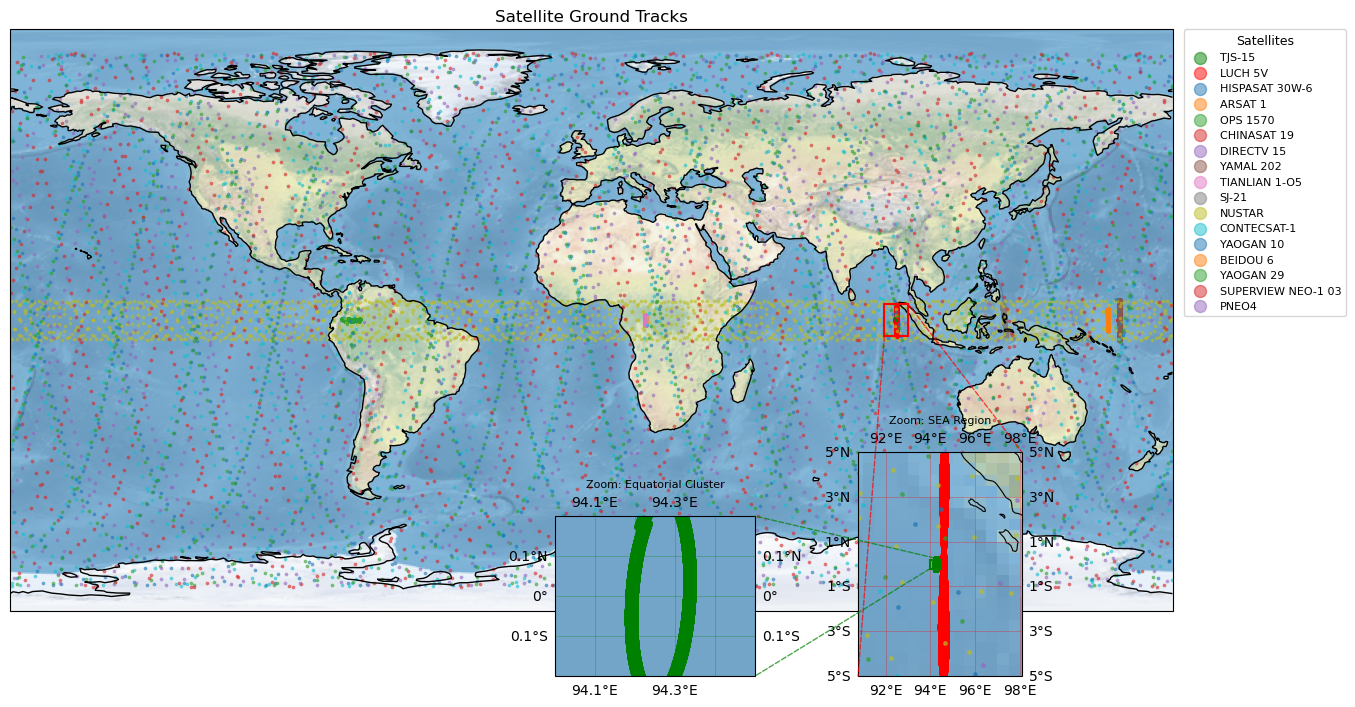

In [9]:
# --- PROPAGATION & PLOTTING ---
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.stock_img()
ax.coastlines()
unique_sats = {sat['NORAD_CAT_ID']: sat for sat in data_list}
scatter_handles = []
scatter_labels = []
tles = OMMUtils.get_tles(data_list)

for norad_id, sat_data in unique_sats.items():
    tle_line_1, tle_line_2 = tles[norad_id][0]
    name = sat_data.get('OBJECT_NAME', f"ID-{norad_id}")
    # Initial State from TLE
    inclination = sat_data['INCLINATION']
    semi_major_axis = sat_data['SEMIMAJOR_AXIS']
    altitude = float(semi_major_axis) - 6378
    eccentricity = sat_data['ECCENTRICITY']

    print('----------------------------')
    print(f"OBJECT NAME: {name}")
    print(f'INCLINATION: {inclination}')
    print(f'ALTITUDE: {altitude}')
    print(f'ECCENTRICITY: {eccentricity}')
    print('----------------------------')

    # Setup Ephemeris for Initial State
    tle_obj = OMMUtils.tle_to_Tle_object(tle_line_1, tle_line_2)
    reference_epoch = tle_obj.reference_epoch
    sat_ephemeris = environment.TleEphemeris("Earth", "J2000", tle_obj, False)
    initial_state = sat_ephemeris.cartesian_state(reference_epoch)

    # Accelerations (Simplified Point Mass)
    accel_settings = {'satellite': {"Earth": [propagation_setup.acceleration.point_mass_gravity()]}}
    accel_models = propagation_setup.create_acceleration_models(system_of_bodies, accel_settings, ['satellite'], ["Earth"])

    # Dependent Variables: Latitude and Longitude
    dep_vars = [
        propagation_setup.dependent_variable.geodetic_latitude('satellite', "Earth"),
        propagation_setup.dependent_variable.longitude('satellite', "Earth")
    ]

    # Termination and Integrator
    if altitude > 30e3:
        termination = propagation_setup.propagator.time_termination(reference_epoch + 86400*3)
    else:
        termination = propagation_setup.propagator.time_termination(reference_epoch + 86400)

    integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step_size(
        initial_time_step=60.0,
        coefficient_set=propagation_setup.integrator.CoefficientSets.rkdp_87
    )

    # Propagate
    prop_settings = propagation_setup.propagator.translational(
        ["Earth"], accel_models, ['satellite'], initial_state, reference_epoch,
        integrator_settings, termination, output_variables=dep_vars
    )

    results = simulator.create_dynamics_simulator(system_of_bodies, prop_settings)
    dep_var_array = result2array(results.propagation_results.dependent_variable_history)

    # Plotting Ground Track
    lats = np.degrees(dep_var_array[:, 1])
    lons = (np.degrees(dep_var_array[:, 2]) + 180) % 360 - 180

    if name == 'LUCH 5V':
        sc = ax.scatter(lons, lats, s=3, label=name, transform=ccrs.Geodetic(), alpha=0.5, color = 'red')
    elif name == 'TJS-15':
        sc = ax.scatter(lons, lats, s=3, label=name, transform=ccrs.Geodetic(), alpha=0.5, color = 'green')
    else:
        sc = ax.scatter(lons, lats, s=3, label=name, transform=ccrs.Geodetic(), alpha=0.5)
    scatter_handles.append(sc)
    scatter_labels.append(name)

ax.set_title("Satellite Ground Tracks")
# --- ZOOM INSET BOUNDS ---
lon_min, lon_max = 90.77, 98.1
lat_min, lat_max = -5.01, 5.01
lon_min_small, lon_max_small = 94.00, 94.5
lat_min_small, lat_max_small = -0.2, 0.2
# --- LARGE INSET (bottom-right of figure) ---
ax_inset = fig.add_axes(
    [0.62, 0.05, 0.25, 0.28],
    projection=ccrs.PlateCarree()
)
ax_inset.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax_inset.stock_img()
ax_inset.coastlines(resolution='50m', linewidth=0.8)
ax_inset.gridlines(draw_labels=True, linewidth=0.4, color='red', alpha=0.5,
                   xlocs=range(int(lon_min), int(lon_max)+1, 2),
                   ylocs=range(int(lat_min), int(lat_max)+1, 2))
ax_inset.set_title("Zoom: SEA Region", fontsize=8)
# Rectangle on MAIN map showing large inset region (red)
rect = Rectangle(
    (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
    linewidth=1.5, edgecolor='red', facecolor='none',
    transform=ccrs.PlateCarree(), zorder=5
)
ax.add_patch(rect)
# Rectangle on LARGE INSET showing small inset region (green)
rect_small_on_inset = Rectangle(
    (lon_min_small, lat_min_small),
    lon_max_small - lon_min_small, lat_max_small - lat_min_small,
    linewidth=1.5, edgecolor='green', facecolor='none',
    transform=ccrs.PlateCarree(), zorder=5
)
ax_inset.add_patch(rect_small_on_inset)
# Rectangle on MAIN map showing small inset region (green)
rect_small_on_main = Rectangle(
    (lon_min_small, lat_min_small),
    lon_max_small - lon_min_small, lat_max_small - lat_min_small,
    linewidth=1.0, edgecolor='green', facecolor='none',
    transform=ccrs.PlateCarree(), zorder=5
)
ax.add_patch(rect_small_on_main)
# --- SMALL INSET ---
ax_inset_small = fig.add_axes(
    [0.43, 0.05, 0.25, 0.20],
    projection=ccrs.PlateCarree()
)
ax_inset_small.set_extent([lon_min_small, lon_max_small, lat_min_small, lat_max_small],
                          crs=ccrs.PlateCarree())
ax_inset_small.stock_img()
ax_inset_small.coastlines(resolution='10m', linewidth=0.8)
ax_inset_small.gridlines(draw_labels=True, linewidth=0.4, color='green', alpha=0.5,
                         xlocs=[94.0, 94.1, 94.2, 94.3, 94.4, 94.5],
                         ylocs=[-0.2, -0.1, 0.0, 0.1, 0.2])
ax_inset_small.set_title("Zoom: Equatorial Cluster", fontsize=8)
# --- RE-PLOT SCATTER DATA ON BOTH INSETS ---
for sc_h in scatter_handles:
    offsets = sc_h.get_offsets()
    lons_i = offsets[:, 0]
    lats_i = offsets[:, 1]
    color = sc_h.get_facecolor()

    ax_inset.scatter(lons_i, lats_i, s=6, color=color,
                     transform=ccrs.Geodetic(), alpha=0.6)
    ax_inset_small.scatter(lons_i, lats_i, s=15, color=color,
                           transform=ccrs.Geodetic(), alpha=0.8)
for xy_main, xy_inset in [
    ((lon_min, lat_min), (0.0, 0.0)),   # bottom-left corner → inset bottom-left
    ((lon_max, lat_max), (1.0, 1.0)),   # bottom-right corner → inset bottom-right
]:
    con = ConnectionPatch(
        xyA=xy_main, coordsA=ccrs.PlateCarree()._as_mpl_transform(ax),
        xyB=xy_inset, coordsB=ax_inset.transAxes,
        arrowstyle="-", color='red', linewidth=1.0, linestyle='--', alpha=0.7,
        zorder=4
    )
    fig.add_artist(con)
for xy_parent, xy_child in [
    ((lon_min_small, lat_min_small), (1.0, 0.0)),   # top-left  → small inset top-left
    ((lon_max_small, lat_max_small), (1.0, 1.0)),   # top-right → small inset top-right
]:
    con = ConnectionPatch(
        xyA=xy_parent, coordsA=ccrs.PlateCarree()._as_mpl_transform(ax_inset),
        xyB=xy_child,  coordsB=ax_inset_small.transAxes,
        arrowstyle="-", color='green', linewidth=1.0, linestyle='--', alpha=0.7,
        zorder=4
    )
    fig.add_artist(con)
# --- LEGEND OUTSIDE MAP ---
legend = ax.legend(
    handles=scatter_handles,
    labels=scatter_labels,
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0,
    markerscale=5,
    fontsize=8,
    title="Satellites",
    title_fontsize=9
)
plt.show()

## Making Sense of the Ground Tracks 
> **NOTE**
>
> **This plot might change over time, as TLEs are dynamical elements. However, since we constrained TJS-15 and LUCH 5V TLEs to a given epoch, the inset should always remain the same.**

This ground track visualization is insightful. We can clearly see a distinction between the high- and low- inclination satellites: the highly inclined ones span the full map in latitude, while the equatorial ones always stay within a given equatorial band.

The insets highlight two notable ground tracks: the green one for **TJS‑15** and the red one for **LUCH 5V**. One appears **almost circular**, while the other traces a **figure‑eight pattern**. This matches what we expect from their respective orbits: **TJS‑15 is geostationary**, whereas **LUCH 5V is geosynchronous**. 

A geostationary satellite’s ground track ideally **collapses to a single point on the equator**; in practice, **small perturbations produce a tiny circular motion**, which is exactly what we see for TJS‑15. By contrast, a geosynchronous orbit with non‑zero inclination or eccentricity produces a characteristic figure‑eight pattern that repeats **every sidereal day**, consistent with the track shown for LUCH 5V.

**Can you spot some other geostationary satellites?**